In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [140]:
df = pd.read_csv('/content/Toyota_Stock_Prices_1980_2026.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803


In [142]:
df['High'].max()

245.7459

In [143]:
df['High'].min()

1.7838

In [152]:
max_high_per_month = df.groupby('Month')['High'].max()
highest_high_month_num = max_high_per_month.idxmax()
highest_high_value = max_high_per_month.max()

# Map month number to month name for better readability
import calendar
highest_high_month_name = calendar.month_abbr[highest_high_month_num]

print(f"The month with the highest 'High' stock price is {highest_high_month_name} (Month {highest_high_month_num}) with a value of {highest_high_value:.2f}.")

The month with the highest 'High' stock price is Mar (Month 3) with a value of 245.75.


In [153]:
df['Day'] = df['Date'].dt.day

In [154]:
avg_high_per_month = df.groupby('Month')['High'].mean()
highest_avg_high_month_num = avg_high_per_month.idxmax()
highest_avg_high_value = avg_high_per_month.max()

import calendar
highest_avg_high_month_name = calendar.month_abbr[highest_avg_high_month_num]

print(f"The month with the highest average 'High' stock price is {highest_avg_high_month_name} (Month {highest_avg_high_month_num}) with an average value of {highest_avg_high_value:.2f}.")

The month with the highest average 'High' stock price is Jan (Month 1) with an average value of 59.38.


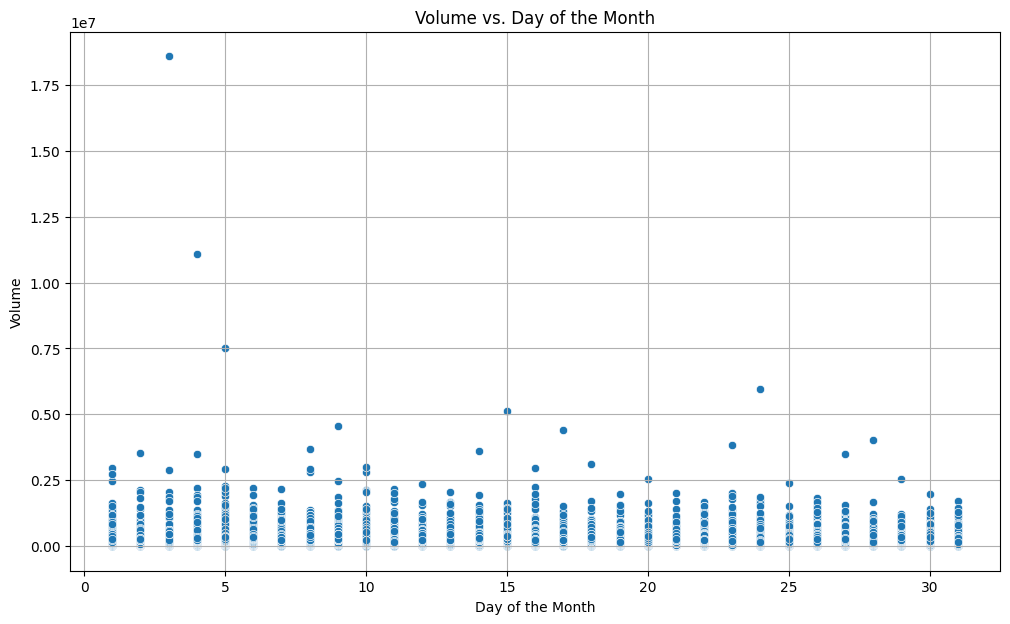

In [155]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Day', y='Volume', data=df)
plt.title('Volume vs. Day of the Month')
plt.xlabel('Day of the Month')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

In [144]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = pearsonr(df['High'], df['Volume'])

print(f"Pearson correlation coefficient between High and Volume: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Since the p-value is less than 0.05, we can conclude there is a statistically significant relationship between High and Volume.")
else:
    print("Since the p-value is greater than or equal to 0.05, we cannot conclude there is a statistically significant relationship between High and Volume.")

Pearson correlation coefficient between High and Volume: 0.2548
P-value: 0.0000
Since the p-value is less than 0.05, we can conclude there is a statistically significant relationship between High and Volume.


In [145]:
from scipy.stats import pearsonr

price_columns = ['Low', 'Close', 'Open']

for col in price_columns:
    correlation, p_value = pearsonr(df[col], df['Volume'])

    print(f"\n--- Analysis for {col} vs. Volume ---")
    print(f"Pearson correlation coefficient between {col} and Volume: {correlation:.4f}")
    print(f"P-value: {p_value:.4f}")

    if p_value < 0.05:
        print(f"Since the p-value is less than 0.05, we can conclude there is a statistically significant relationship between {col} and Volume.")
    else:
        print(f"Since the p-value is greater than or equal to 0.05, we cannot conclude there is a statistically significant relationship between {col} and Volume.")


--- Analysis for Low vs. Volume ---
Pearson correlation coefficient between Low and Volume: 0.2515
P-value: 0.0000
Since the p-value is less than 0.05, we can conclude there is a statistically significant relationship between Low and Volume.

--- Analysis for Close vs. Volume ---
Pearson correlation coefficient between Close and Volume: 0.2534
P-value: 0.0000
Since the p-value is less than 0.05, we can conclude there is a statistically significant relationship between Close and Volume.

--- Analysis for Open vs. Volume ---
Pearson correlation coefficient between Open and Volume: 0.2534
P-value: 0.0000
Since the p-value is less than 0.05, we can conclude there is a statistically significant relationship between Open and Volume.


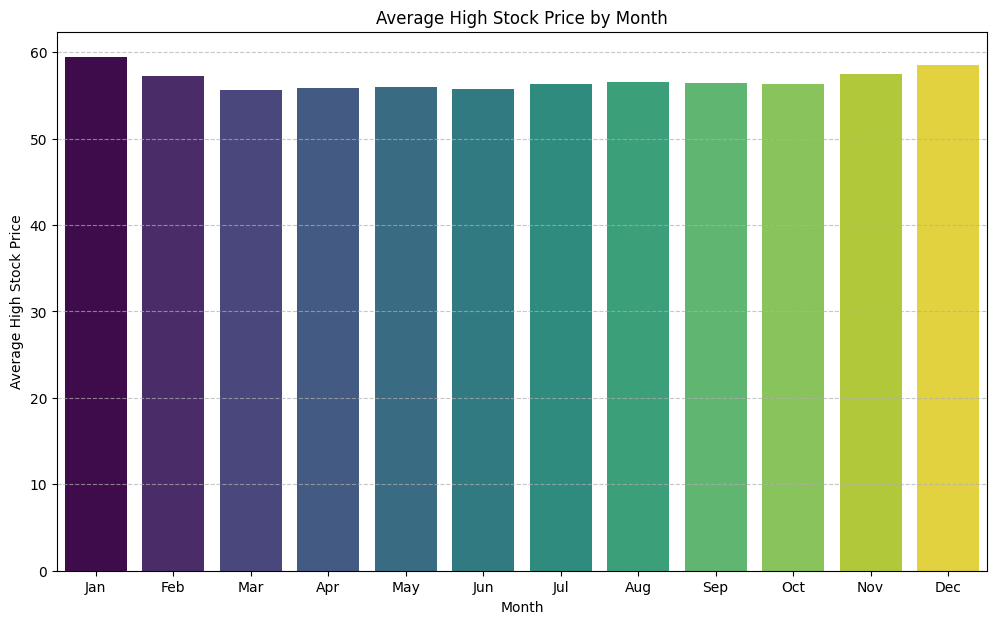

In [146]:
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_high_per_month.index, y=avg_high_per_month.values, hue=avg_high_per_month.index, palette='viridis', legend=False)
plt.title('Average High Stock Price by Month')
plt.xlabel('Month')
plt.ylabel('Average High Stock Price')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [147]:
df['Volume'].max()

18582700

In [148]:
highest_volume_date = df.loc[df['Volume'].idxmax(), 'Date']
print(f"The date with the highest volume was: {highest_volume_date}")

The date with the highest volume was: 2010-02-03


In [149]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month


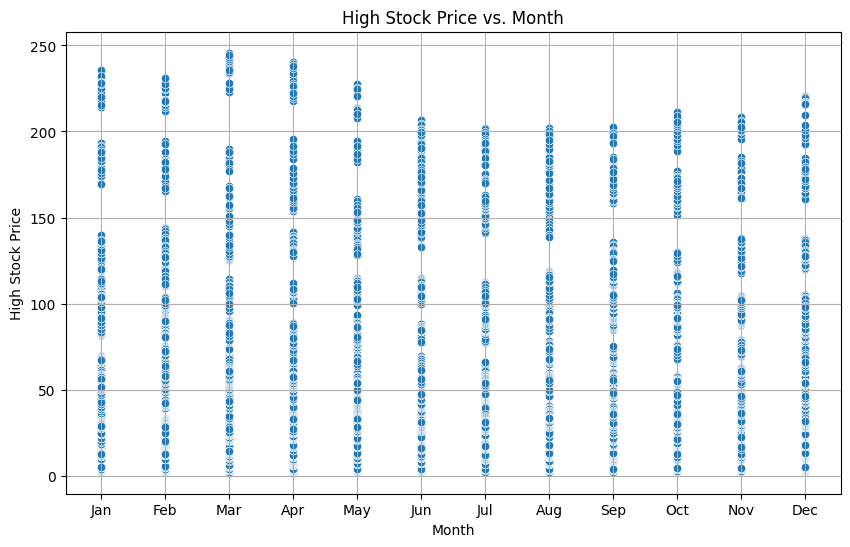

In [150]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Month', y='High', data=df)
plt.title('High Stock Price vs. Month')
plt.xlabel('Month')
plt.ylabel('High Stock Price')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.show()

Correlation Matrix for Open, Close, Low, High, and Volume:
            Open     Close       Low      High    Volume
Open    1.000000  0.999932  0.999962  0.999965  0.253411
Close   0.999932  1.000000  0.999966  0.999967  0.253369
Low     0.999962  0.999966  1.000000  0.999947  0.251466
High    0.999965  0.999967  0.999947  1.000000  0.254762
Volume  0.253411  0.253369  0.251466  0.254762  1.000000


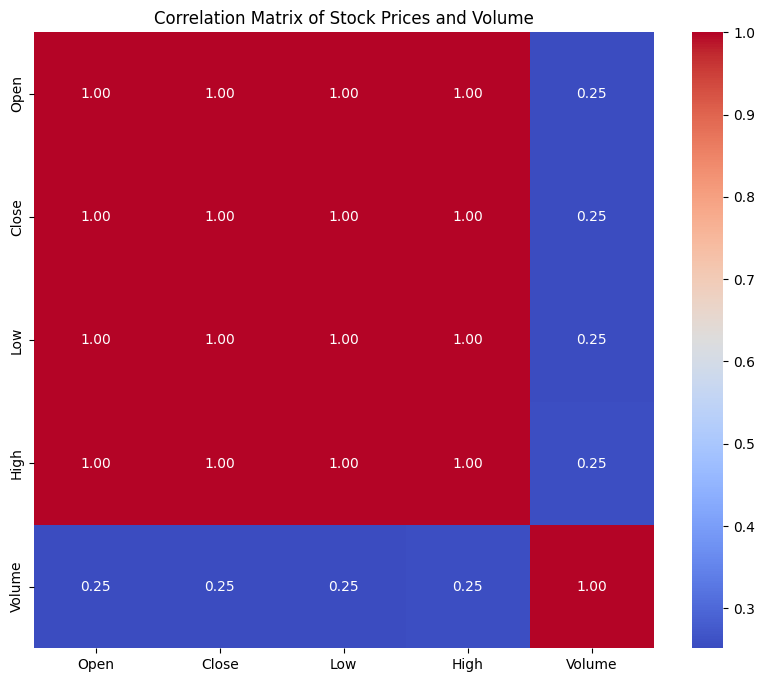

In [151]:
price_volume_columns = ['Open', 'Close', 'Low', 'High', 'Volume']
correlation_matrix = df[price_volume_columns].corr()
print("Correlation Matrix for Open, Close, Low, High, and Volume:")
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Prices and Volume')
plt.show()

# Task
Calculate and visualize the average daily returns by month using the 'Close' price from the `/content/Toyota_Stock_Prices_1980_2026.csv` dataset, and summarize any insights from the plot.

## Calculate Daily Returns

### Subtask:
Calculate the daily returns based on the 'Close' price and store them in a new column.


**Reasoning**:
To calculate the daily returns, I will use the `.pct_change()` method on the 'Close' price column and store the result in a new column named 'Daily Return'.



In [133]:
df['Daily Return'] = df['Close'].pct_change()
df.head(10)

,Date,Close,High,Low,Open,Volume,Month,Day,Daily Return
0,1980-03-18,1.8207,1.8501,1.8207,1.8207,9343,3,18,NaN
1,1980-03-19,1.8207,1.8207,1.8207,1.8207,0,3,19,0.000000
2,1980-03-20,1.8207,1.8501,1.8207,1.8207,10277,3,20,0.000000
3,1980-03-21,1.8649,1.8944,1.8649,1.8649,8409,3,21,0.024276
4,1980-03-24,1.8723,1.9017,1.8723,1.8723,2803,3,24,0.003968
5,1980-03-25,1.8575,1.8870,1.8575,1.8723,27095,3,25,-0.007905
6,1980-03-26,1.8575,1.8870,1.8575,1.8575,1869,3,26,0.000000
7,1980-03-27,1.8354,1.8649,1.8354,1.8575,14015,3,27,-0.011898
8,1980-03-28,1.8280,1.8575,1.8280,1.8354,36438,3,28,-0.004032
9,1980-03-31,1.8280,1.8575,1.8280,1.8280,1869,3,31,0.000000


**Reasoning**:
Now that daily returns have been calculated, the next step is to group the DataFrame by month and calculate the average daily return for each month. This will prepare the data for visualization as requested in the main task.



In [134]:
avg_daily_returns_monthly = df.groupby('Month')['Daily Return'].mean()
print("Average Daily Returns by Month:")
print(avg_daily_returns_monthly)

Average Daily Returns by Month:
Month
1     0.000039
2    -0.000149
3     0.000891
4     0.001743
5    -0.000179
6     0.000935
7     0.000203
8    -0.000202
9     0.000600
10    0.000518
11    0.000533
12    0.002060
Name: Daily Return, dtype: float64


**Reasoning**:
To visualize the average daily returns by month as requested by the main task, I will create a bar plot using the `avg_daily_returns_monthly` Series. This will allow for easy comparison of returns across different months.



/tmp/ipython-input-872/869935612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_daily_returns_monthly.index, y=avg_daily_returns_monthly.values, palette='viridis')


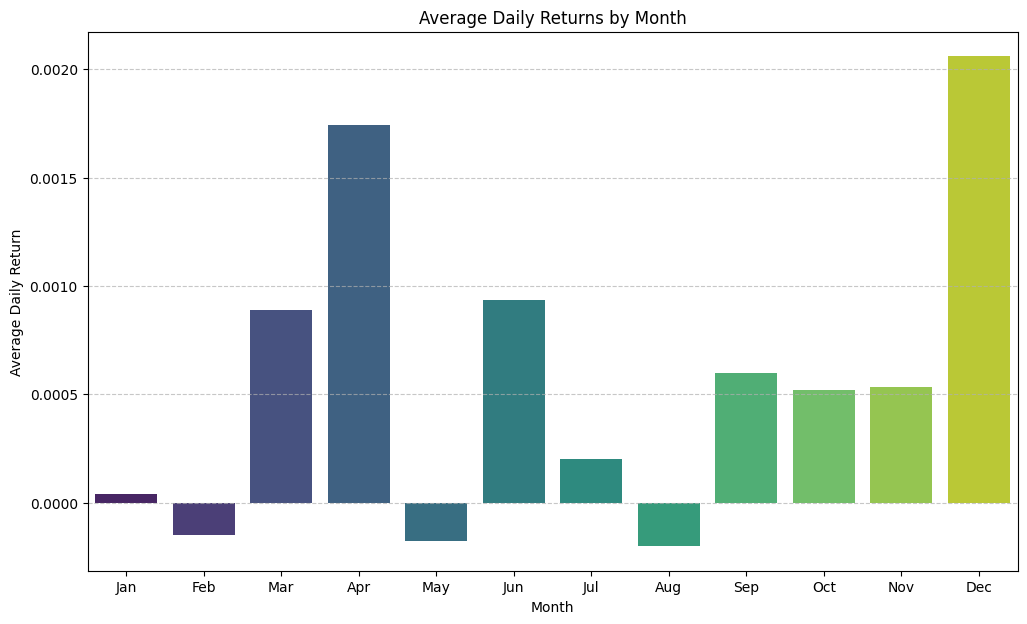

In [135]:
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_daily_returns_monthly.index, y=avg_daily_returns_monthly.values, palette='viridis')
plt.title('Average Daily Returns by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Return')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-872/2421838669.py:23: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  recent = df.last('2Y')
/tmp/ipython-input-872/2421838669.py:23: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  recent = df.last('2Y')


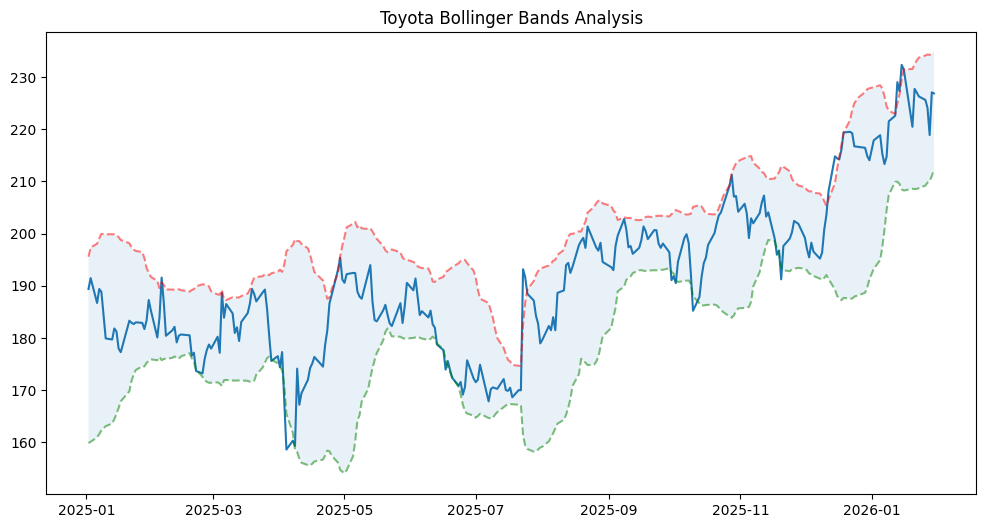

In [156]:
# Load Data
df = pd.read_csv('/content/Toyota_Stock_Prices_1980_2026.csv', index_col='Date', parse_dates=True)

# 1. MACD Calculation
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# 2. RSI Calculation
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['RSI'] = 100 - (100 / (1 + (gain / loss)))

# 3. Bollinger Bands
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['Std_Dev'] = df['Close'].rolling(window=20).std()
df['Upper_Band'] = df['SMA_20'] + (df['Std_Dev'] * 2)
df['Lower_Band'] = df['SMA_20'] - (df['Std_Dev'] * 2)

# Visualization (Last 2 Years)
recent = df.last('2Y')
plt.figure(figsize=(12,6))
plt.plot(recent.index, recent['Close'], label='Close')
plt.plot(recent.index, recent['Upper_Band'], 'r--', alpha=0.5)
plt.plot(recent.index, recent['Lower_Band'], 'g--', alpha=0.5)
plt.fill_between(recent.index, recent['Lower_Band'], recent['Upper_Band'], alpha=0.1)
plt.title('Toyota Bollinger Bands Analysis')
plt.show()

## Moving Average Convergence Divergence (MACD) Analysis for 2025

### Visualization of MACD for 2024-2025

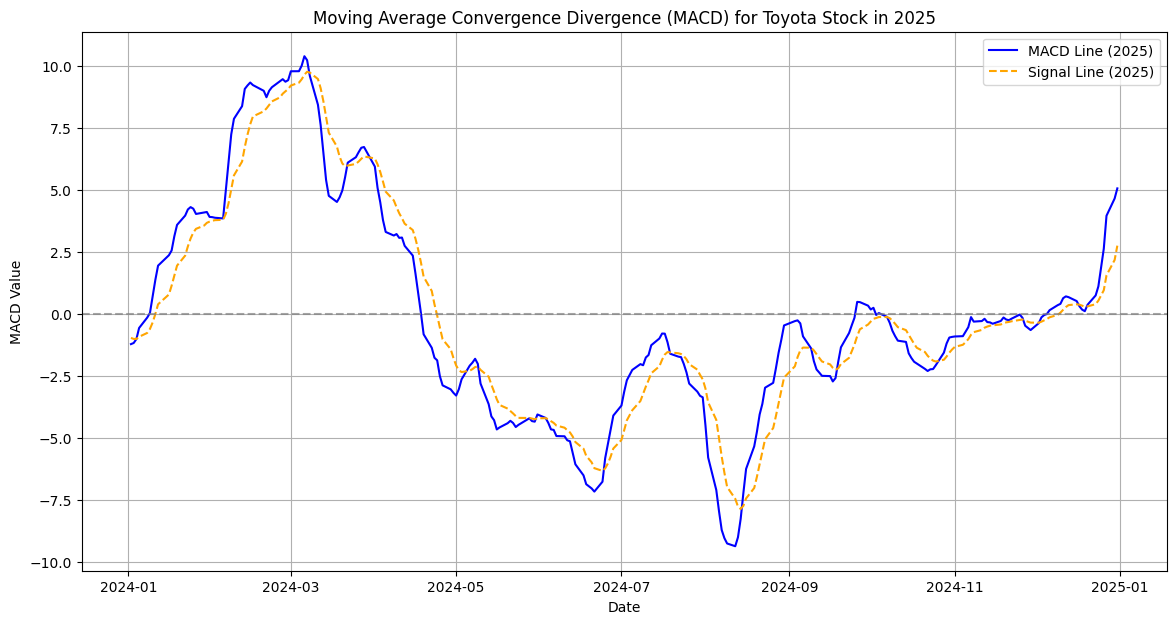

In [137]:
# Filter data for the year 2024-2025
df_2025_macd = df.loc['2024,2025']

plt.figure(figsize=(14, 7))
plt.plot(df_2025_macd.index, df_2025_macd['MACD'], label='MACD Line (2025)', color='blue')
plt.plot(df_2025_macd.index, df_2025_macd['Signal'], label='Signal Line (2025)', color='orange', linestyle='--')
plt.axhline(0, color='grey', linestyle='--', alpha=0.7)
plt.title('Moving Average Convergence Divergence (MACD) for Toyota Stock in 2025')
plt.xlabel('Date')
plt.ylabel('MACD Value')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of MACD Plot for 2024-2025

This plot displays the Moving Average Convergence Divergence (MACD) and its Signal Line for Toyota stock in 2025. The MACD is a trend-following momentum indicator that shows the relationship between two moving averages of a security’s price.

*   **MACD Line (Blue):** This is the difference between the 12-period and 26-period Exponential Moving Averages (EMAs).
*   **Signal Line (Orange, Dashed):** This is a 9-period EMA of the MACD Line.

**Key Observations for 2025:**

*   **Crossovers:** When the MACD line crosses above the Signal line, it is generally considered a bullish signal, suggesting upward momentum. Conversely, when the MACD line crosses below the Signal line, it is often a bearish signal, indicating downward momentum.
*   **Divergence:** Divergences between the MACD and the stock price (e.g., price makes a new high but MACD makes a lower high) can signal potential trend reversals.
*   **Zero Line Crossovers:** When the MACD line crosses above the zero line, it can indicate a shift from bearish to bullish momentum, and vice-versa when it crosses below the zero line.

By examining these elements in the 2024-2025 MACD plot, one can gain insights into the specific short-term and medium-term momentum trends and potential trading signals during that year.

## Relative Strength Index (RSI) Analysis for 2024-2025

### Visualization of RSI for 2024-2025

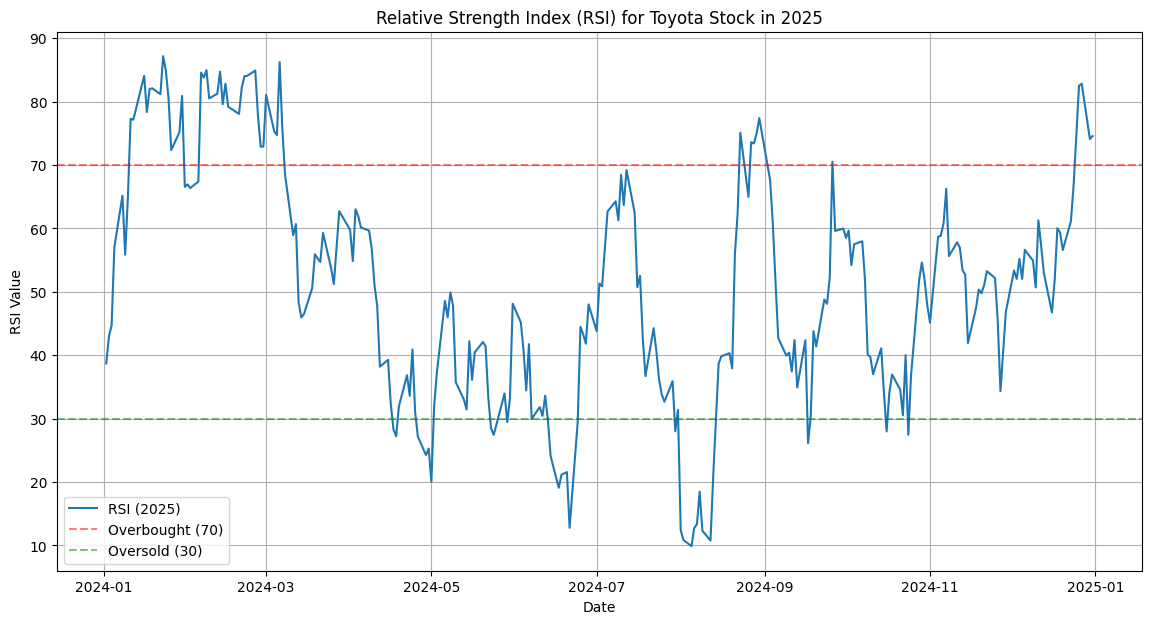

In [138]:
# Filter data for the year 2024-2025
df_2025 = df.loc['2024,2025']

plt.figure(figsize=(14, 7))
plt.plot(df_2025.index, df_2025['RSI'], label='RSI (2025)')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
plt.title('Relative Strength Index (RSI) for Toyota Stock in 2025')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of RSI Plot for 2024-2025

This plot specifically shows the Relative Strength Index (RSI) for Toyota stock during the year 2025. Similar to the general interpretation, the RSI helps identify momentum and potential reversals:

*   **Overbought Conditions (RSI > 70):** Periods where the RSI crosses above 70 suggest that the stock might have been overbought in 2025, potentially indicating a short-term price correction or consolidation.

*   **Oversold Conditions (RSI < 30):** Periods where the RSI falls below 30 suggest that the stock might have been oversold in 2025, potentially indicating a rebound opportunity.

By focusing on 2024-2025, we can observe specific instances within that year where the stock exhibited strong buying or selling pressure, allowing for a more granular analysis of its momentum trends during that particular period.